
an online retail dataset


#Task 1 – Data Import & Setup


In [1]:
import pandas as pd

df = pd.read_excel("https://raw.githubusercontent.com/Srinithi-python/Assignment4online-retail-dataset/refs/heads/main/Online%20Retail.xlsx")
print(f'HEAD:')
print(df.head())
print(f'')
print(f'TAIL:')
print(df.tail())
print(f'')
print(f'SHAPE:')
print(df.shape)
print(f'')
print(f'COLUMN NAMES:')
print(df.columns)
print(f'')
print(f'Convert InvoiceDate to datetime:')
print(f'BEFORE FORMATTING')
print(df["InvoiceDate"].dtype)
print(f'')
print(f'AFTER FORMATTING')
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
print(df["InvoiceDate"].dtype)

HEAD:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  

TAIL:
       InvoiceNo StockCode                      Description  Quantity  \
541904    581587     22613      PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899    

#Task 2 – Data Cleaning

In [3]:
import pandas as pd

df = pd.read_excel("https://raw.githubusercontent.com/Srinithi-python/Assignment4online-retail-dataset/refs/heads/main/Online%20Retail.xlsx")

print(f'Convert InvoiceDate to datetime:')
print(f'AFTER FORMATTING')
print(f'')
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
print(df["InvoiceDate"])
print(f'')
print(f"Before:", df.shape)
print(f"")
print(f"Handle missing values (remove null CustomerID)")
df = df.dropna(subset=["CustomerID"])
print(f"After removal of null customerID:", df.shape)
print(f"")
print(f"Total Duplicates records are :", df.duplicated().sum())

df = df.drop_duplicates()
df = df.reset_index(drop=True)
print(f"After removal of duplicate records:")
print(df.shape)
print(f"")
print(f"Remove negative Quantity")
df.loc[df["Quantity"] < 0, "Quantity"] = 0

mean_price = df.loc[df["UnitPrice"] > 0, "UnitPrice"].mean()
df.loc[df["UnitPrice"] <= 0, "UnitPrice"] = mean_price
df["UnitPrice"] = df["UnitPrice"].fillna(mean_price)

print(df.shape)
print(f"")
print(f"Remove invalid UnitPrice")
df = df[df["UnitPrice"] > 0]
print(df.shape)

print(f"")
print(df.head(20))

Convert InvoiceDate to datetime:
BEFORE FORMATTING
0        2010-12-01 08:26:00
1        2010-12-01 08:26:00
2        2010-12-01 08:26:00
3        2010-12-01 08:26:00
4        2010-12-01 08:26:00
                 ...        
541904   2011-12-09 12:50:00
541905   2011-12-09 12:50:00
541906   2011-12-09 12:50:00
541907   2011-12-09 12:50:00
541908   2011-12-09 12:50:00
Name: InvoiceDate, Length: 541909, dtype: datetime64[ns]

AFTER FORMATTING
0        2010-12-01 08:26:00
1        2010-12-01 08:26:00
2        2010-12-01 08:26:00
3        2010-12-01 08:26:00
4        2010-12-01 08:26:00
                 ...        
541904   2011-12-09 12:50:00
541905   2011-12-09 12:50:00
541906   2011-12-09 12:50:00
541907   2011-12-09 12:50:00
541908   2011-12-09 12:50:00
Name: InvoiceDate, Length: 541909, dtype: datetime64[ns]
Before: (541909, 8)

Handle missing values (remove null CustomerID)
After removal of null customerID: (406829, 8)

Total Duplicates records are : 5225
After removal of duplicate r

#Task 3 – Feature Engineering

In [13]:

df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]
print(f"After changes")
print(df[["Quantity", "UnitPrice", "TotalPrice"]].head())

df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.to_period("M")
df["Day"] = df["InvoiceDate"].dt.day
df["Hour"] = df["InvoiceDate"].dt.hour
df["Day Type"] = df["InvoiceDate"].dt.dayofweek.apply(lambda x: "Weekend" if x >= 5 else "Weekday")
print(f'')
print(f"Extract time features (Year, Month, Day, Hour)")
print(df[["Year", "Month", "Day","Hour","Day Type"]].head(10))

print(df)
print(df.columns)

customer_total = df.groupby("CustomerID")["TotalPrice"].transform("sum")
df["Customer Segment"] = pd.cut(customer_total,bins=[-float("inf"), 500, 2000, float("inf")],labels=["Low Value", "Medium Value", "High Value"])
df["Order Size"] = pd.cut(df["Quantity"],bins=[-float("inf"), 10, 50, float("inf")],labels=["Small", "Medium", "Large"])
print(f'')
print(df[["CustomerID","Quantity","InvoiceDate","Customer Segment","Order Size","Day Type"]].head())




After changes
   Quantity  UnitPrice  TotalPrice
0         6       2.55       15.30
1         6       3.39       20.34
2         8       2.75       22.00
3         6       3.39       20.34
4         6       3.39       20.34

Extract time features (Year, Month, Day, Hour)
   Year    Month  Day  Hour Day Type
0  2010  2010-12    1     8  Weekday
1  2010  2010-12    1     8  Weekday
2  2010  2010-12    1     8  Weekday
3  2010  2010-12    1     8  Weekday
4  2010  2010-12    1     8  Weekday
5  2010  2010-12    1     8  Weekday
6  2010  2010-12    1     8  Weekday
7  2010  2010-12    1     8  Weekday
8  2010  2010-12    1     8  Weekday
9  2010  2010-12    1     8  Weekday
       InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536

#Task 4 – Data Exploration

In [17]:

print("Overview Of DataSet:::")

print(f"Shape of dataset =>", df.shape)
print(f"Column Names of dataset=>")
print(df.columns.tolist())
print(f'')
print(f"Data Types of all the columns in the datast:")
print(df.dtypes)
print(f'')
print(f"Missing Values=>")
print(df.isnull().sum())
print(f'')
print(f"Statistical Summary=>")
print(df.describe())
print(f'')
print(f"Duplicate Rows=>", df.duplicated().sum())


print(f'Country:::::Counts')
print(df["Country"].value_counts())
print(f'')
print(df["Country"].unique())


print(f'CustomerID::::::Details')
print(df["CustomerID"].value_counts())
print(f'')
print(df["CustomerID"].unique())

print(f'InvoiceNo:::::Counts')
print(df["InvoiceNo"].value_counts())
print(f'')
print(df["InvoiceNo"].unique())

print(f'StockCode:::::Counts')
print(df["StockCode"].value_counts())
print(f'')
print(df["StockCode"].unique())
print(f"")

print(f'')
print(df.groupby("Country")["TotalPrice"].sum())
country_Orders_list=df.groupby("Country").agg(TotalRevenue=("TotalPrice","sum"),TotalOrders=("InvoiceNo", "nunique"))
print(f"country_Orders_list")
print(country_Orders_list)
print(f'')
monthly_orders = df.groupby("Month")["InvoiceNo"].nunique()
print(f"monthly_orders")
print(monthly_orders)
print(f'')
product_rev=df.groupby("StockCode")["TotalPrice"].sum().sort_values(ascending=False)
print(f"product_rev:::::")
print(product_rev)
print(f'')
country_product = (df.groupby(["Country", "StockCode","Month"])["TotalPrice"].sum().reset_index())
print(f"country_product group by Country, stockCode,Month:::::")
print(country_product)


Overview Of DataSet:::
Shape of dataset => (401604, 16)
Column Names of dataset=>
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'Year', 'Month', 'Day', 'Hour', 'Day Type', 'Customer Segment', 'Order Size']

Data Types of all the columns in the datast:
InvoiceNo                   object
StockCode                   object
Description                 object
Quantity                     int64
InvoiceDate         datetime64[ns]
UnitPrice                  float64
CustomerID                 float64
Country                     object
TotalPrice                 float64
Year                         int32
Month                    period[M]
Day                          int32
Hour                         int32
Day Type                    object
Customer Segment          category
Order Size                category
dtype: object

Missing Values=>
InvoiceNo           0
StockCode           0
Description         0
Quantity       

# Task 5 – Data Wrangling

In [18]:
country_agg_data=(df.groupby("Country").agg(TotalRevenue=("TotalPrice","sum"),TotalOrders=("InvoiceNo","nunique"),TotalQuantity=("Quantity","sum"),AveragePrice=("UnitPrice","mean")).reset_index())
country_agg_data
print(f"Aggregrated Data displayed below baed on country:::::")
print(f"")
print(country_agg_data)
print(f"")
country_data=(df.groupby(["CustomerID","Country"]).agg(TotalRevenue=("TotalPrice","sum")).reset_index())
country_data
print(f"Aggregrated Data displayed below based on CustomerID Country:::::")
print(f"")
print(country_data)
print(f"")
top_country_details=country_data.sort_values("TotalRevenue",ascending=False).reset_index()
print(f"Sorted data Aggregrated Data displayed below:::::")
print(top_country_details.head(10))
print(f"")
pivot_df = pd.pivot_table(df,values="TotalPrice",index="Country",columns="Month",aggfunc="sum")
print(f"Pivot table :::::")
print(pivot_df)
print(f"")

Aggregrated Data displayed below baed on country:::::

                 Country  TotalRevenue  TotalOrders  TotalQuantity  \
0              Australia  1.395239e+05           69          84199   
1                Austria  1.019868e+04           19           4881   
2                Bahrain  5.484000e+02            2            260   
3                Belgium  4.119634e+04          119          23237   
4                 Brazil  1.143600e+03            1            356   
5                 Canada  3.666380e+03            6           2763   
6        Channel Islands  2.044054e+04           33           9485   
7                 Cyprus  1.350285e+04           20           6340   
8         Czech Republic  8.267400e+02            5            671   
9                Denmark  1.895534e+04           21           8235   
10                  EIRE  2.661311e+05          319         140383   
11    European Community  1.300250e+03            5            499   
12               Finland  2.254608e

#Task 6 – Statistical Analysis

In [19]:
print(f"Quantity Analysis")
print(f"Mean:", df["Quantity"].mean())
print(f"Minimum:", df["Quantity"].min())
print(f"Maximum:", df["Quantity"].max())
print(f"Total:", df["Quantity"].sum())

print(f'')
print(f"UnitPrice Analysis ")
print(f"Mean:", df["UnitPrice"].mean())
print(f"Minimum:", df["UnitPrice"].min())
print(f"Maximum:", df["UnitPrice"].max())
print(f'')

print(f"TotalPrice Analysis")
print(f"Mean:", df["TotalPrice"].mean())
print(f"Minimum:", df["TotalPrice"].min())
print(f"Maximum:", df["TotalPrice"].max())
print(f"Total Revenue:", df["TotalPrice"].sum())

print(f"Mean Median Mode details are displayed below::::")
columns = ["Quantity", "UnitPrice", "TotalPrice"]
print(f'')
for col in columns:
  print(f"--- {col} ---")
  print("Mean=>", df[col].mean())
  print("Median=>", df[col].median())
  print("Mode=>", df[col].mode()[0])
  print("Standard Deviation=>", df[col].std())
  print("Variance=>", df[col].var())
  print("25th Percentile=>", df[col].quantile(0.25))
  print("50th Percentile=>", df[col].quantile(0.50))
  print("75th Percentile=>", df[col].quantile(0.75))
  print(f'')

Quantity Analysis
Mean: 12.863133833328353
Minimum: 0
Maximum: 80995
Total: 5165886

UnitPrice Analysis 
Mean: 3.4744096930999806
Minimum: 0.001
Maximum: 38970.0

TotalPrice Analysis
Mean: 22.249398905835104
Minimum: 0.0
Maximum: 168469.6
Total Revenue: 8935447.598179001
Mean Median Mode details are displayed below::::

--- Quantity ---
Mean=> 12.863133833328353
Median=> 5.0
Mode=> 1
Standard Deviation=> 179.5818478020161
Variance=> 32249.64005998648
25th Percentile=> 2.0
50th Percentile=> 5.0
75th Percentile=> 12.0

--- UnitPrice ---
Mean=> 3.4744096930999806
Median=> 1.95
Mode=> 1.25
Standard Deviation=> 69.76402644783336
Variance=> 4867.019386213993
25th Percentile=> 1.25
50th Percentile=> 1.95
75th Percentile=> 3.75

--- TotalPrice ---
Mean=> 22.249398905835104
Median=> 11.7
Mode=> 15.0
Standard Deviation=> 315.23579930355464
Variance=> 99373.60916255099
25th Percentile=> 4.25
50th Percentile=> 11.7
75th Percentile=> 19.799999999999997



# Task 7 – Data Visualization (Min 8 Plots)

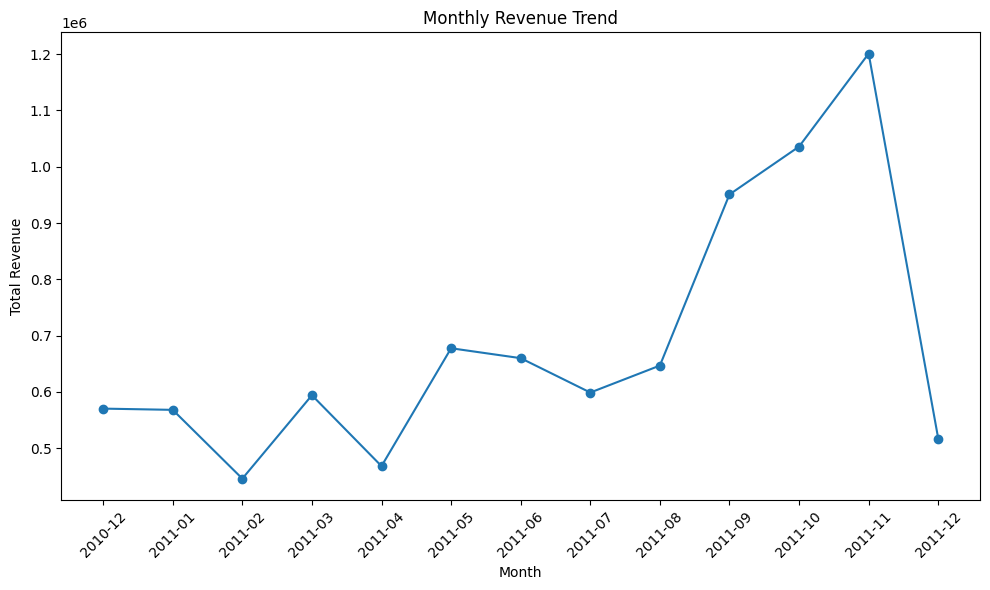

In [21]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
monthlyRevenue=(df.groupby("Month")["TotalPrice"].sum().reset_index())
plt.plot(monthlyRevenue["Month"].astype(str), monthlyRevenue["TotalPrice"],marker="o")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Line Chart

Highest-revenue month => 2011-11
lowest-revenue month=> 2011-02

# Bar chart

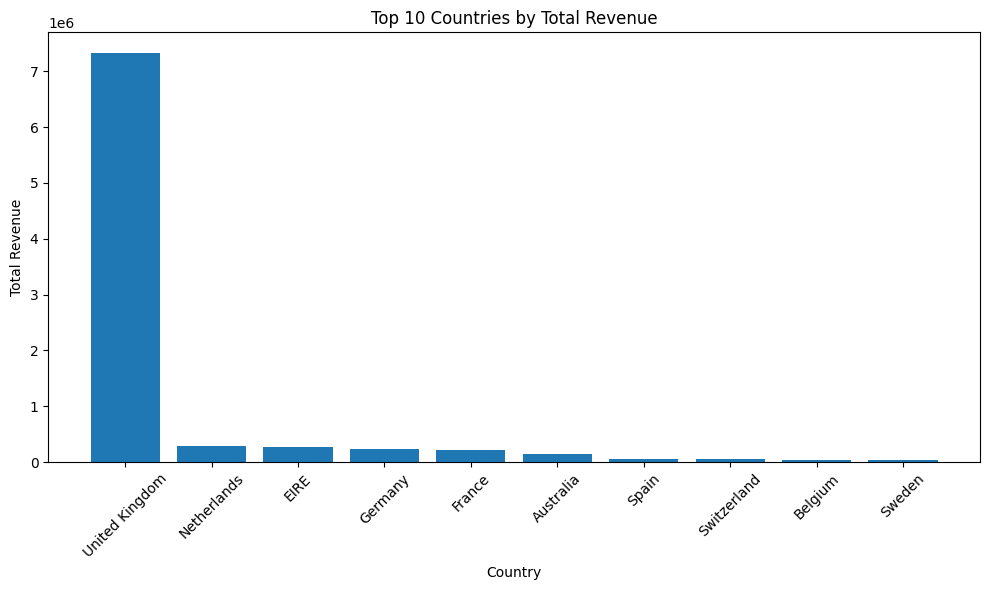

In [22]:
import matplotlib.pyplot as plt

country_revenue = (df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10))
plt.figure(figsize=(10, 6))
plt.bar(country_revenue.index,country_revenue.values)
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.title("Top 10 Countries by Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Highest purchase of products are made in United Kingdom
Lowest purchase of products are made in Spain,Belgium,sweden

#Histogram

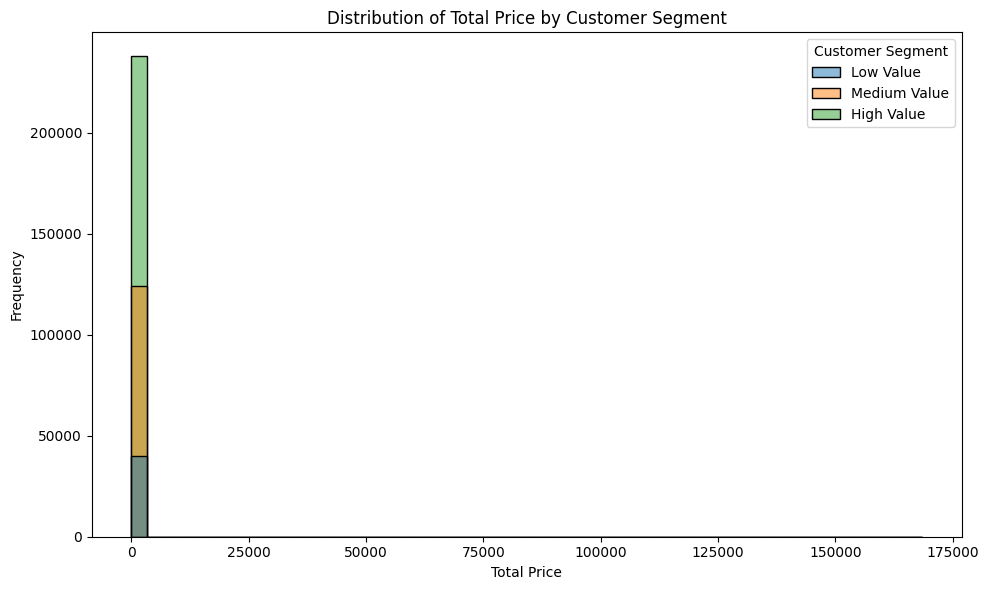

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(data=df,x="TotalPrice",hue="Customer Segment",bins=50,multiple="layer")
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.title("Distribution of Total Price by Customer Segment")
plt.tight_layout()
plt.show()

#Box plot

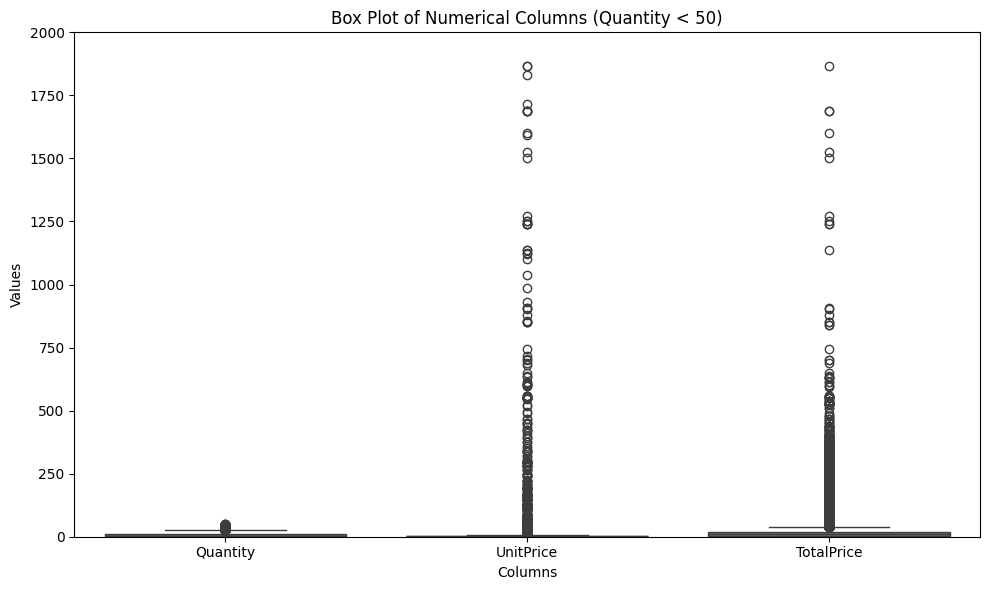

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

filtered_df = df[df["Quantity"] < 50]
plt.figure(figsize=(10, 6))
sns.boxplot(data=filtered_df[["Quantity", "UnitPrice", "TotalPrice"]])
plt.xlabel("Columns")
plt.ylabel("Values")
plt.ylim(0, 2000)
plt.title("Box Plot of Numerical Columns (Quantity < 50)")

plt.tight_layout()
plt.show()

#Seaborn


Seaborn:
● Count plot
● Violin plot
● Heatmap
● Pair plot

#Count plot

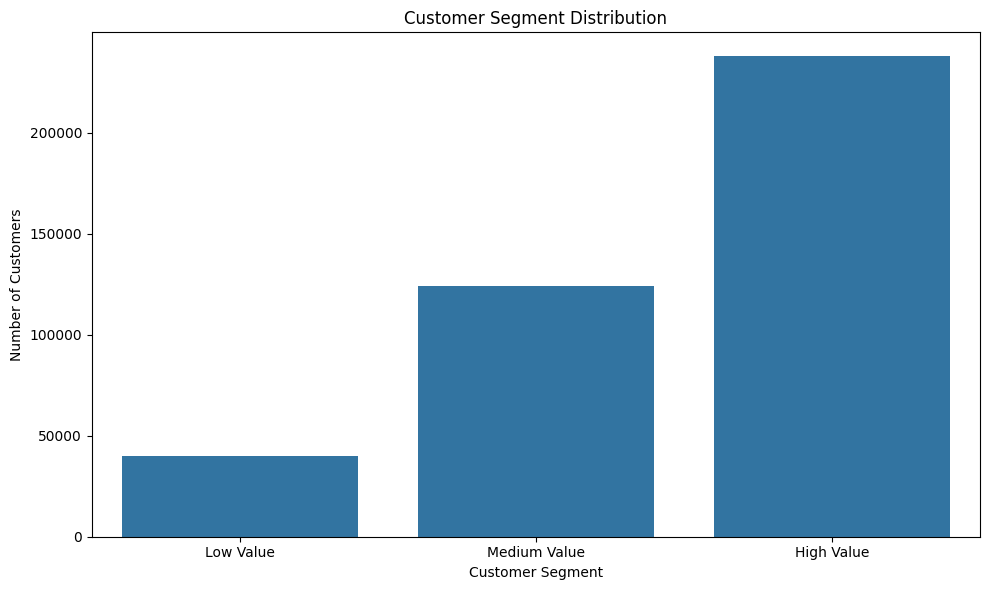

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.countplot(data=df,x="Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.title("Customer Segment Distribution")
plt.tight_layout()
plt.show()

#Violin plot

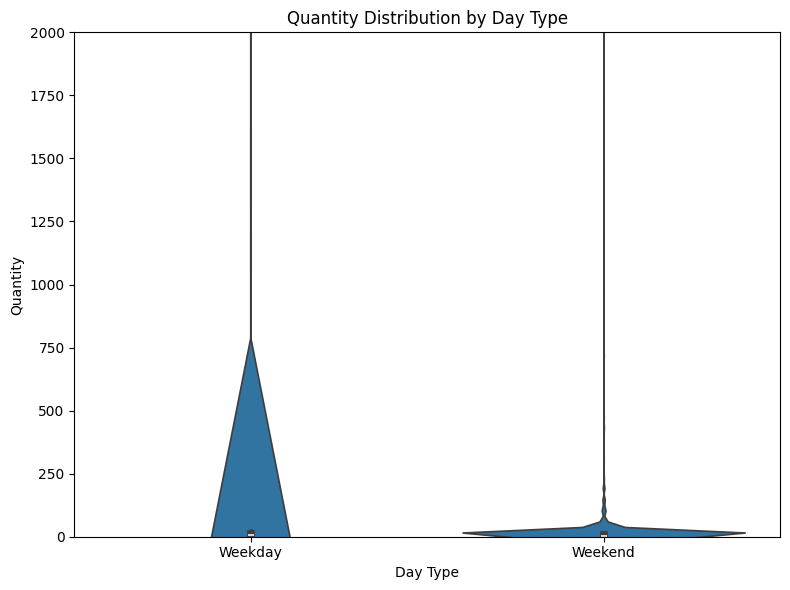

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.violinplot(data=df,x="Day Type",y="Quantity")
plt.xlabel("Day Type")
plt.ylabel("Quantity")

plt.ylim(0, 2000)
plt.title("Quantity Distribution by Day Type")

plt.tight_layout()
plt.show()

#Heatmap

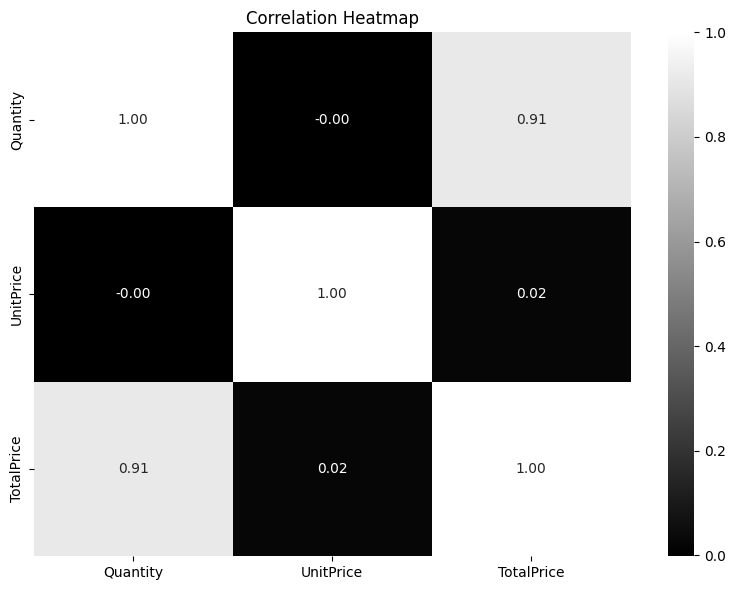

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[["Quantity", "UnitPrice", "TotalPrice"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr,annot=True,cmap="gist_gray",fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

#Pair plot

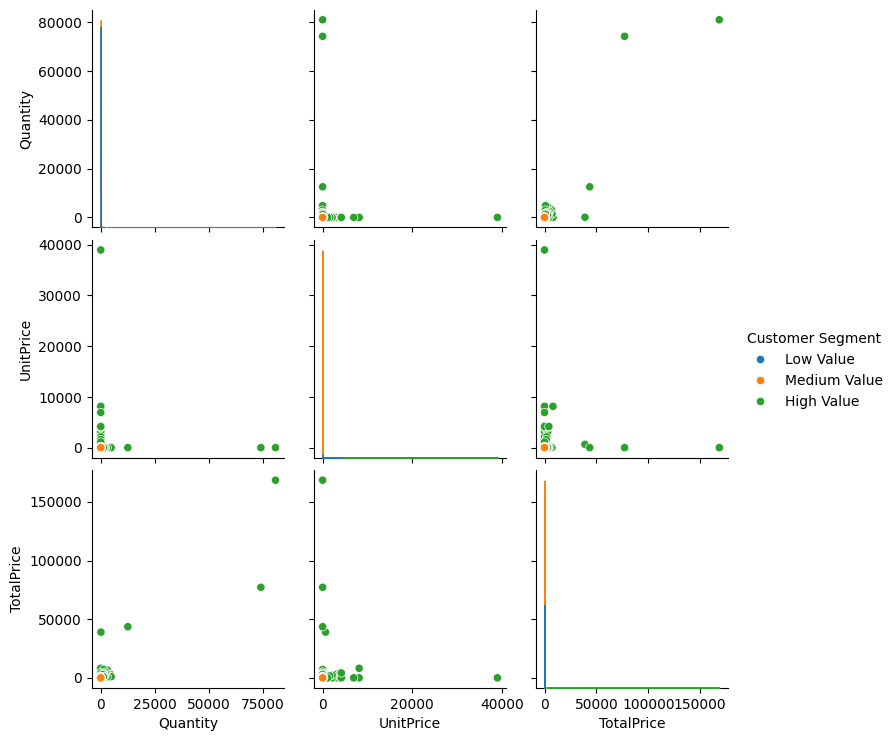

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df[["Quantity", "UnitPrice", "TotalPrice", "Customer Segment"]],hue="Customer Segment")
plt.show()

# Task 8 – Business Insights

In [35]:
import pandas as pd

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Month"] = df["InvoiceDate"].dt.to_period("M")
df["Hour"] = df["InvoiceDate"].dt.hour
top_country = (df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(1))
best_month = (df.groupby("Month")["TotalPrice"].sum().sort_values(ascending=False).head(1))
peak_hour = (df.groupby("Hour")["TotalPrice"].sum().sort_values(ascending=False).head(1))
print("Top Country:")
print(top_country)
print(f"")
print("Best Sales Month:")
print(best_month)
print(f"")
print("Peak Sales Time:")
print(peak_hour)

Top Country:
Country
United Kingdom    7.329261e+06
Name: TotalPrice, dtype: float64

Best Sales Month:
Month
2011-11    1.200807e+06
Freq: M, Name: TotalPrice, dtype: float64

Peak Sales Time:
Hour
12    1.373723e+06
Name: TotalPrice, dtype: float64


In [37]:

customer_behavior = (df.groupby("CustomerID").agg(TotalOrders=("InvoiceNo", "nunique"),TotalQuantity=("Quantity", "sum"),TotalSpending=("TotalPrice", "sum")).reset_index())
high_value_customers = (customer_behavior.sort_values("TotalSpending", ascending=False).head(10))
top_products = (df.groupby("StockCode").agg(TotalRevenue=("TotalPrice", "sum"),TotalQuantity=("Quantity", "sum"),TotalOrders=("InvoiceNo", "nunique")).sort_values("TotalRevenue", ascending=False).head(10).reset_index())
print("Customer Behaviour")
print(customer_behavior.head())
print(f"")
print("High value customers")
print(high_value_customers)
print(f"")
print("Top Products")
print(top_products)

Customer Behaviour
   CustomerID  TotalOrders  TotalQuantity  TotalSpending
0     12346.0            2          74215       77183.60
1     12347.0            7           2458        4310.00
2     12348.0            4           2341        1797.24
3     12349.0            1            631        1757.55
4     12350.0            1            197         334.40

High value customers
      CustomerID  TotalOrders  TotalQuantity  TotalSpending
1703     14646.0           77         197491  282207.279983
4233     18102.0           62          64124  259657.300000
3758     17450.0           55          69973  194390.790000
3033     16446.0            3          80997  168472.500000
1895     14911.0          248          80490  144579.772423
55       12415.0           26          77670  125942.955269
1345     14156.0           66          57768  117210.080000
3801     17511.0           46          64549   91062.380000
2722     16029.0           76          40108   80850.840000
0        12346.0 